# Константы, импорты

In [213]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

TARGET = "stroke"

DATASET_PATH = "./healthcare-dataset-stroke-data.xls"

numeric_cols = ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
numeric_cols_without_id = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Загрузка данных

In [214]:
df = pd.read_csv(DATASET_PATH)
print('Размер:', df.shape)
print(df[TARGET].value_counts())
df.head()

Размер: (5110, 12)
stroke
0    4861
1     249
Name: count, dtype: int64


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Анализ сырых данных

Анализ данных до преобразования категориальных признаков

## Базовый анализ, взгляд на данные

In [215]:
print('=== Типы данных, количество пропусков ===')
df.info()

=== Типы данных, количество пропусков ===
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [216]:
print('=== Статистика по числовым и категориальным признакам ===')
df.describe(include='all')

=== Статистика по числовым и категориальным признакам ===


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


In [217]:
print ('=== Количество уникальных значений по колонкам (категориальные колонки) ===')
for col in cat_cols:
    print(f'{col}: {df[col].nunique()}')

=== Количество уникальных значений по колонкам (категориальные колонки) ===
gender: 3
ever_married: 2
work_type: 5
Residence_type: 2
smoking_status: 4


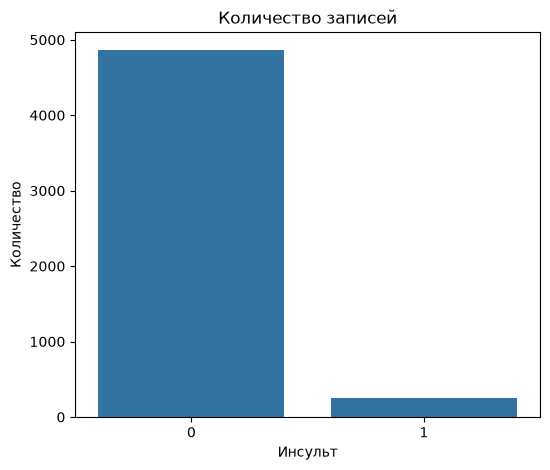

In [218]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x=TARGET)
plt.xlabel('Инсульт')
plt.ylabel('Количество')
plt.title('Количество записей')
plt.show()

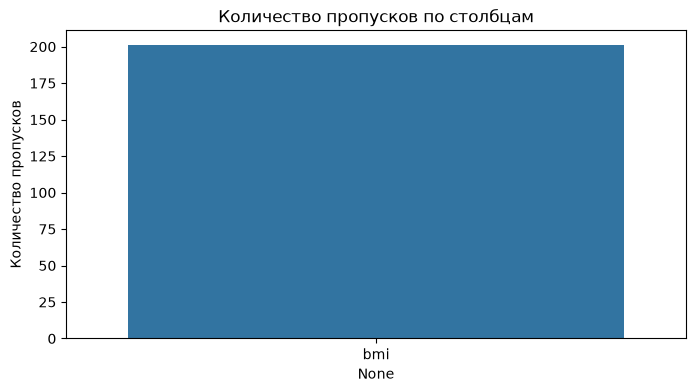

In [219]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=missing.index, y=missing.values)
plt.title('Количество пропусков по столбцам')
plt.ylabel('Количество пропусков')
plt.show()

## Анализ числовых признаков

### Анализ распределения (ящики с усами)

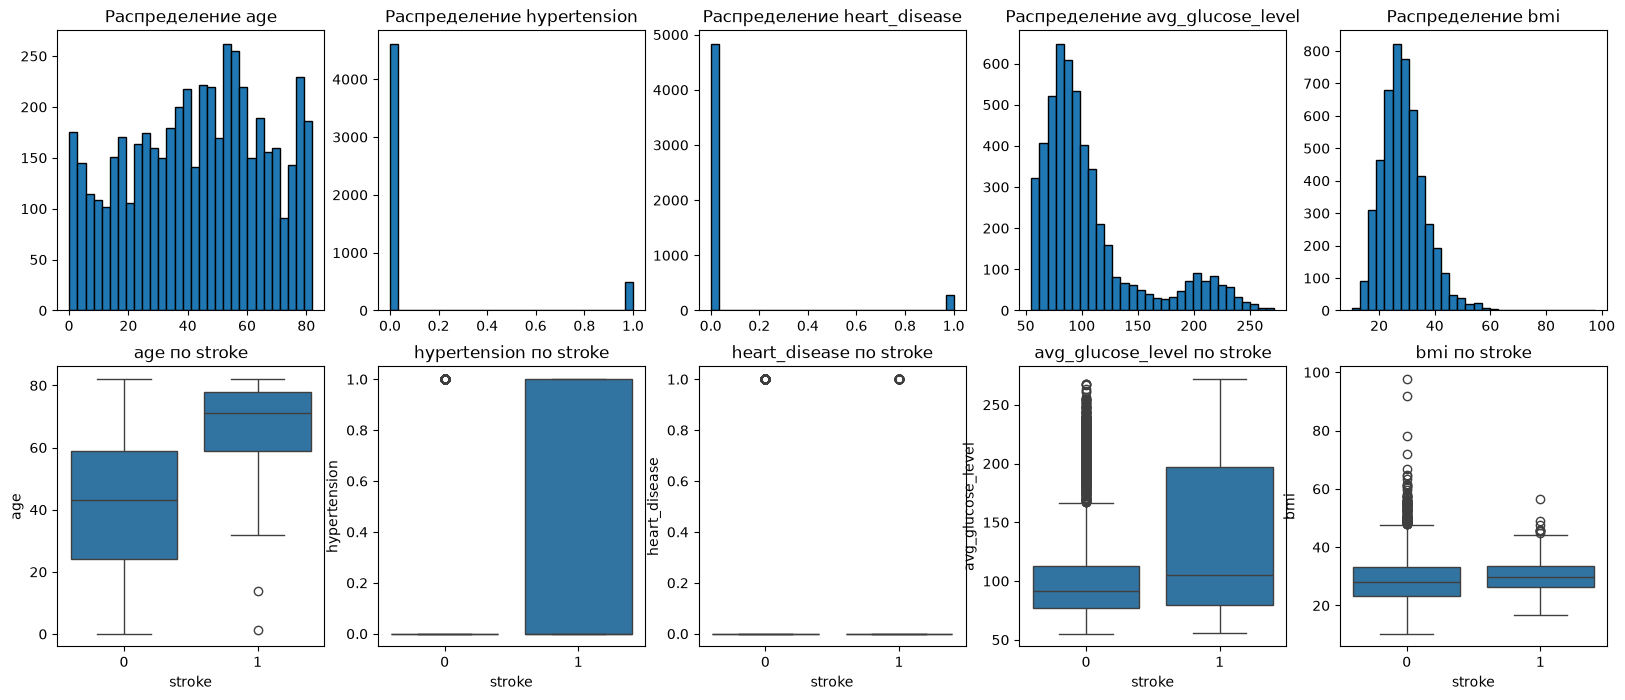

In [220]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, col in enumerate(numeric_cols_without_id):
    axes[0, i].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[0, i].set_title(f'Распределение {col}')
    
    # Boxplot по классам stroke
    sns.boxplot(data=df, x=TARGET, y=col, ax=axes[1, i])
    axes[1, i].set_title(f'{col} по {TARGET}')

### Анализ распределения (Skewness)

In [221]:
from scipy.stats import skew
print(df[numeric_cols].apply(skew))

id                  -0.019907
age                 -0.137019
hypertension         2.714595
heart_disease        3.946085
avg_glucose_level    1.571822
bmi                       NaN
dtype: float64


### Анализ выбросов

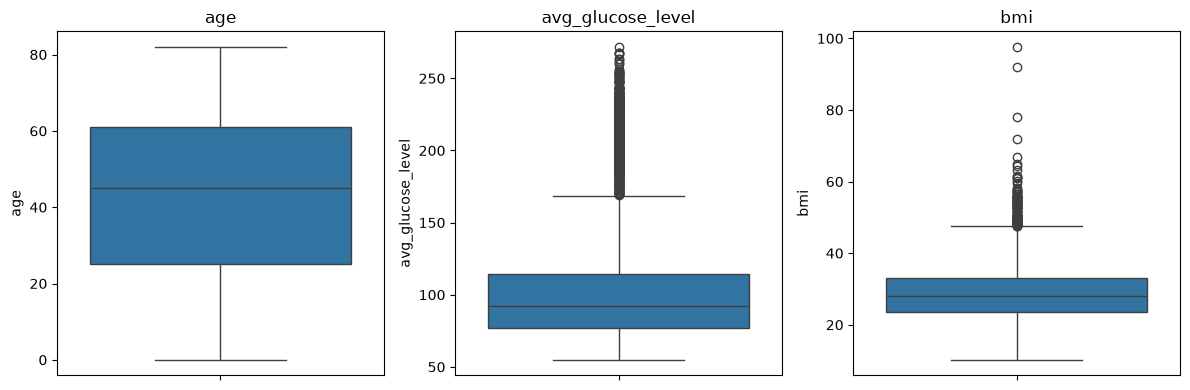

In [222]:
plt.figure(figsize=(12,4))
num_cols = ['age', 'avg_glucose_level', 'bmi']
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Анализ категориальных признаков

### Столбчатые диаграммы для категориальных признаков

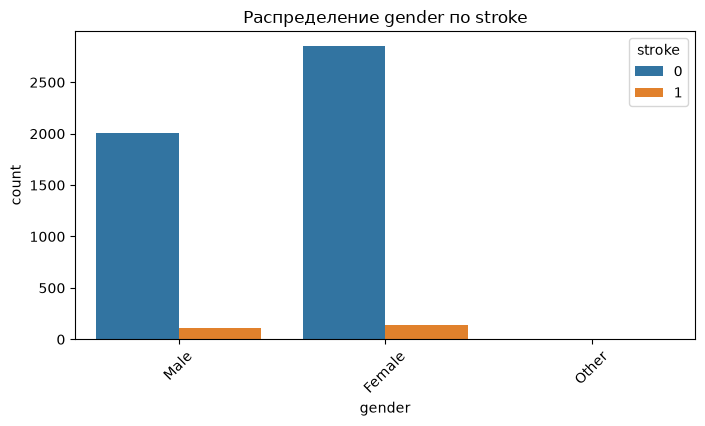

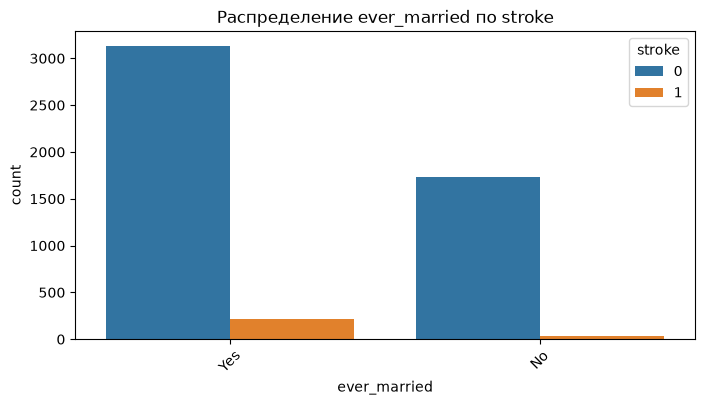

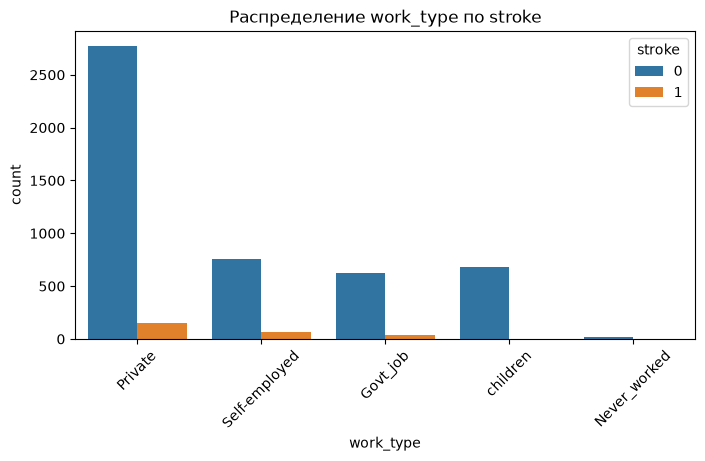

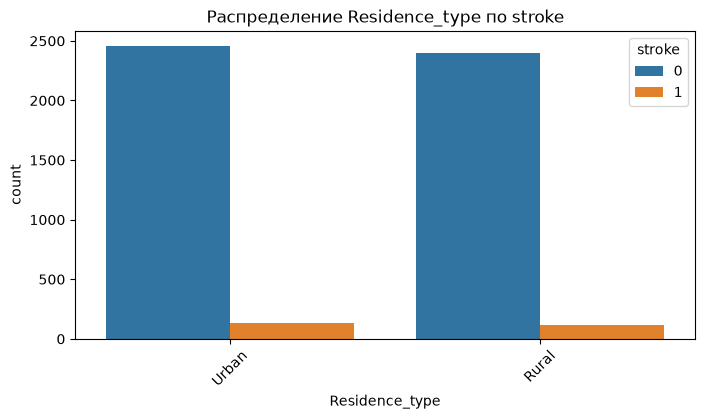

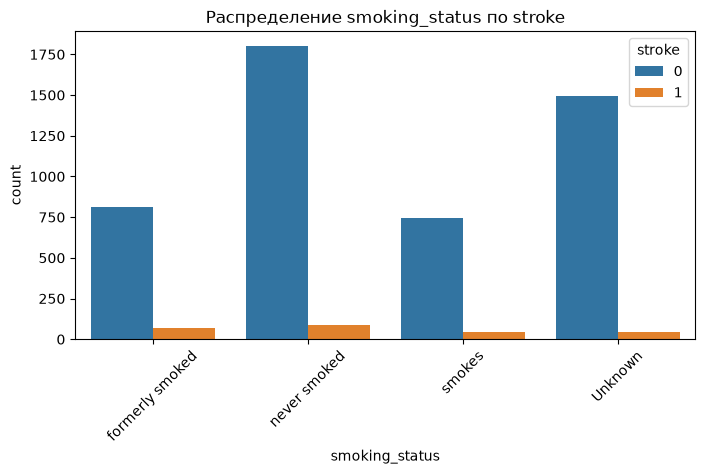

In [223]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='stroke')
    plt.title(f'Распределение {col} по stroke')
    plt.xticks(rotation=45)
    plt.show()

# Подготовка данных. Преобразование категориальных признаков

In [224]:
df.dropna(inplace=True)

X = df.drop(TARGET, axis=1)
y = df[TARGET]

label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1610
)

C:\Users\Aleksei\AppData\Local\Temp\ipykernel_17200\2955529132.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


# Анализ данных после преобразования

## HeatMap параметров

C:\Users\Aleksei\AppData\Local\Temp\ipykernel_17200\157479483.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_stroke.values, y=corr_with_stroke.index, palette='coolwarm')


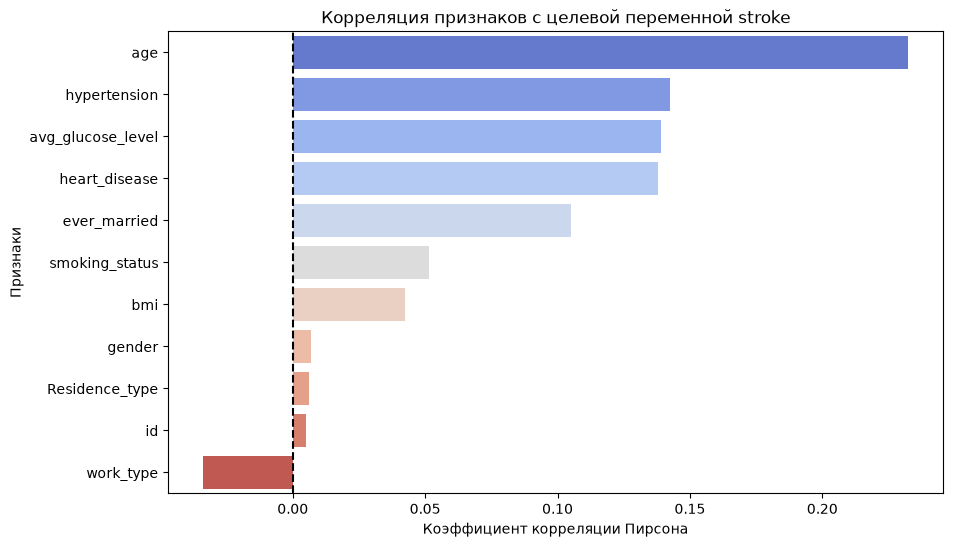

In [233]:
df_encoded = X.copy()
df_encoded[TARGET] = y

corr = df_encoded.corr()

corr_with_stroke = corr[TARGET].drop(TARGET).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_stroke.values, y=corr_with_stroke.index, palette='coolwarm')
plt.title('Корреляция признаков с целевой переменной ' + TARGET)
plt.xlabel('Коэффициент корреляции Пирсона')
plt.ylabel('Признаки')
plt.axvline(0, color='black', linestyle='--')
plt.show()

# Обучение модели

In [226]:
model = DecisionTreeClassifier(random_state=1610)
model.fit(X_train, y_train)

# Предсказания на тесте
y_pred = model.predict(X_test)

# Оценка качества

In [227]:
def print_metrics_explained(y_true, y_pred, target_names):
    """
    Печатает краткое объяснение метрик классификации.
    """
    report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    acc = report['accuracy']
    
    print(f"Accuracy: {acc:.4f}  ({acc*100:.2f}% правильных ответов)")
    
    for name in target_names:
        m = report[name]
        print(f"\nКласс '{name}':")
        print(f"  precision = {m['precision']:.2f}  ({m['precision']*100:.0f}% предсказанных верны)")
        print(f"  recall    = {m['recall']:.2f}    ({m['recall']*100:.0f}% реальных найдены)")
        print(f"  f1-score  = {m['f1-score']:.2f}")
    
    macro = report['macro avg']
    weighted = report['weighted avg']
    print("\nСредние:")
    print(f"  macro avg    precision={macro['precision']:.2f}, recall={macro['recall']:.2f}, f1={macro['f1-score']:.2f}")
    print(f"  weighted avg precision={weighted['precision']:.2f}, recall={weighted['recall']:.2f}, f1={weighted['f1-score']:.2f}")

In [228]:
print_metrics_explained(y_test, y_pred, ['Нет инсульта', 'Инсульт'])

Accuracy: 0.9318  (93.18% правильных ответов)

Класс 'Нет инсульта':
  precision = 0.97  (97% предсказанных верны)
  recall    = 0.96    (96% реальных найдены)
  f1-score  = 0.96

Класс 'Инсульт':
  precision = 0.12  (12% предсказанных верны)
  recall    = 0.19    (19% реальных найдены)
  f1-score  = 0.15

Средние:
  macro avg    precision=0.55, recall=0.57, f1=0.56
  weighted avg precision=0.95, recall=0.93, f1=0.94


# График "Предсказание VS Реальность"

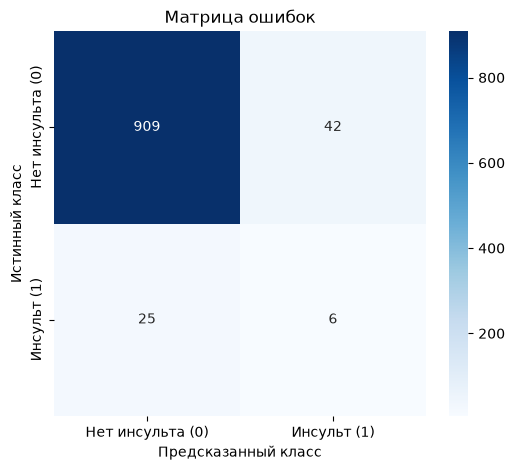

In [229]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Нет инсульта (0)', 'Инсульт (1)'],
            yticklabels=['Нет инсульта (0)', 'Инсульт (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()